# Distributed Group Lasso Regression
## Parameter Definition and Centralized Optimization

The centralized optimization problem is defined as
$$
\min_{x \in \mathbb{R}^{12}} 
\quad 
\sum_{i=1}^{4}
\left(
\|A_i x - b_i\|_2^2
+ \lambda \|x^{(i)}\|_2
\right),
$$
where the decision variable is partitioned into four disjoint blocks
$$
x = \big[(x^{(1)})^\top, (x^{(2)})^\top, (x^{(3)})^\top, (x^{(4)})^\top\big]^\top,
\qquad x^{(i)} \in \mathbb{R}^3,
$$
and the optimal solution is denoted by $x^\star$.

The communication network among agents is modeled as a ring topology.
The corresponding gossip matrix is defined as
$$
W = I - 0.2 L,
$$
where $L$ denotes the Laplacian matrix of the communication graph.

In [1]:
import numpy as np
import numpy.typing as npt

# 4 nodes, 4 groups, each group has size 3
from conops import Graph

L = np.array([[2, -1, 0, -1], [-1, 2, -1, 0], [0, -1, 2, -1], [-1, 0, -1, 2]])
W = np.eye(4) - L * 0.2

graph = Graph.from_mixing_matrix(W, transport="ipc")
n_nodes = graph.number_of_nodes
nodes = graph.nodes
group_size = 3
dim = n_nodes * group_size  # 12W

import numpy.random as npr

npr.seed(0)

# ----- group structure -----
groups = {
    "1": list(range(0, 3)),
    "2": list(range(3, 6)),
    "3": list(range(6, 9)),
    "4": list(range(9, 12)),
}

# ----- ground truth (group sparse) -----
# only group 1 and group 3 are active
x_tilde = np.zeros(dim)
x_tilde[groups["1"]] = npr.normal(0.0, 1.0, group_size)
x_tilde[groups["3"]] = npr.normal(0.0, 1.0, group_size)

# ----- local data -----
# each node holds A_i and b_i
m = 20  # number of samples per node

A = {i: npr.normal(0.0, 1.0, (m, dim)) / np.sqrt(m) for i in nodes}
eps = {i: npr.normal(0.0, 0.05, m) for i in nodes}
b = {i: A[i] @ x_tilde + eps[i] for i in nodes}

# ----- centralized reference solution (group lasso) -----
import cvxpy as cp

x = cp.Variable(dim)

lam = 5.0

loss = cp.sum([cp.sum_squares(A[i] @ x - b[i]) for i in nodes])

group_penalty = 0
for i in nodes:
    idx = groups[i]
    group_penalty += cp.norm(x[idx], 2)

prob = cp.Problem(cp.Minimize(loss + lam * group_penalty))
prob.solve(solver=cp.ECOS)

x_star: npt.NDArray[np.float64] = x.value  # type: ignore

print("Groups:", groups)
print("Optimal solution x*:", x_star)

Groups: {'1': [0, 1, 2], '2': [3, 4, 5], '3': [6, 7, 8], '4': [9, 10, 11]}
Optimal solution x*: [ 1.16416945e+00  1.21184673e-01  6.01122370e-01  7.44961549e-11
  6.24987191e-10  6.01113212e-10  1.86045801e+00  1.66380011e+00
 -7.00201015e-01  5.54424142e-10  3.53356467e-10 -7.91165912e-10]


## Benchmarking Distributed Optimization Algorithms

In this section, we benchmark the distributed optimization algorithms `EXTRA`, `NIDS`, `DIGing`, `AugDGM`, `WE`, and `RGT` on the ridge regression problem.
Each algorithm is executed with its respective step size, and their performance is compared in terms of mean squared error (MSE)

$$
\frac{1}{4d} \sum_{i = 1}^{4} || x_i - x^* ||^2
$$

over iterations, where $x_i, x^* \in \mathbb{R}^d$.

In [ ]:
import ray

# ray.init(address="auto") for multi-node setup
# ray.init(address="local") for local multi-process setup
ray.init(address="local")


@ray.remote
class Agent:
    def __init__(
        self,
        node_id: str,
        dimension: int,
        a_i: npt.NDArray[np.float64],
        b_i: npt.NDArray[np.float64],
        lam_i: float,
        group_i: list[int],
    ):
        self.dimension = dimension
        self.a_i = a_i
        self.b_i = b_i
        self.lam_i = lam_i
        self.group_i = group_i

        from conops import NodeHandle

        self.handle = NodeHandle(node_id, transport="ipc")

        self.max_iter = 100

        from dco import Optimizer, EXTRA, NIDS, DIGing, AugDGM, RGT, RAugDGM, WE, AtcWE

        self.optim_cls: dict[str, type[Optimizer]] = {
            "EXTRA": EXTRA,
            "NIDS": NIDS,
            "DIGing": DIGing,
            "AugDGM": AugDGM,
            "RGT": RGT,
            "RAugDGM": RAugDGM,
            "WE": WE,
            "AtcWE": AtcWE,
        }

    @ray.method
    def group_lasso(self, optim_name: str, gamma: float) -> npt.NDArray[np.float64]:
        import numpy as np

        x_i = np.zeros((self.max_iter, self.dimension), dtype=np.float64)

        # Define loss function
        def f(var: npt.NDArray[np.float64]) -> np.float64:
            return np.sum((self.a_i @ var - self.b_i) ** 2)

        from dco import GroupLasso

        reg = GroupLasso(lam=self.lam_i, groups=[self.group_i])

        # Create optimizer and run iterations
        optimizer = self.optim_cls[optim_name](f, self.handle, gamma, reg=reg)

        optimizer.init(x_i[0])

        for k in range(self.max_iter - 1):
            x_i[k + 1] = optimizer.step(x_i[k])

        return x_i


import logging

logging.basicConfig(level=logging.INFO)

from conops import bootstrap

bootstrap(graph)
agents = [Agent.remote(i, dim, A[i], b[i], lam, groups[i]) for i in nodes]

2026-04-14 17:37:59,632	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


INFO:conops.bootstrap:Node '4' joined graph 'default' from @conops-default-4.
INFO:conops.bootstrap:Node '3' joined graph 'default' from @conops-default-3.
INFO:conops.bootstrap:Node '2' joined graph 'default' from @conops-default-2.
INFO:conops.bootstrap:Node '1' joined graph 'default' from @conops-default-1.
INFO:conops.bootstrap:Graph 'default' registration complete.
INFO:conops.bootstrap:Sent neighbor info to all nodes in graph 'default'.


In [9]:
step_sizes = {
    "EXTRA": 0.15,
    "NIDS": 0.15,
    "DIGing": 0.15,
    "AugDGM": 0.15,
    "WE": 0.15,
    "RGT": 0.15,
    "AtcWE": 0.15,
    "RAugDGM": 0.15,
}

local_histories: dict[str, list[npt.NDArray[np.float64]]] = {}

for alg, gam in step_sizes.items():
    refs = [agent.group_lasso.remote(alg, gam) for agent in agents]
    local_histories[alg] = [ray.get(ref) for ref in refs]
    print(f"Algorithm: {alg}, Step size: {gam}, Finished!")

Algorithm: EXTRA, Step size: 0.15, Finished!
Algorithm: NIDS, Step size: 0.15, Finished!
Algorithm: DIGing, Step size: 0.15, Finished!
Algorithm: AugDGM, Step size: 0.15, Finished!
Algorithm: WE, Step size: 0.15, Finished!
Algorithm: RGT, Step size: 0.15, Finished!
Algorithm: AtcWE, Step size: 0.15, Finished!
Algorithm: RAugDGM, Step size: 0.15, Finished!


## Plot the results

### Global Matplotlib Plotting Parameters and Sensor Color Scheme

In [10]:
import matplotlib.pyplot as plt
from numpy import mean, stack

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
    }
)

### MSE for robust algorithms `RAugDGM`, `RGT`, `WE`, and `RGT`

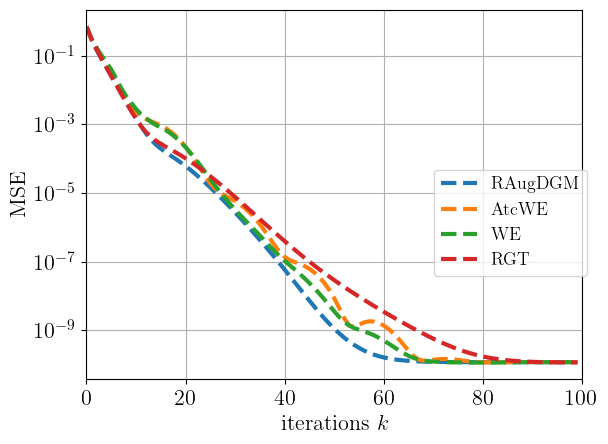

In [11]:
fig, ax = plt.subplots()

line_options = {"linewidth": 3, "linestyle": "--"}

hh: list[npt.NDArray[np.float64]] = []

robust_algorithms = ["RAugDGM", "AtcWE", "WE", "RGT"]
for alg in robust_algorithms:
    histories = local_histories[alg]
    # shape: (n_nodes, n_iter, dim)
    stacked_histories = stack(histories)
    # shape: (n_nodes, n_iter)
    mse_evolution_nodes = mean((stacked_histories - x_star) ** 2, axis=2)
    mse_evolution = mean(mse_evolution_nodes, axis=0)
    ax.semilogy(mse_evolution, label=alg, **line_options)
    hh.append(mse_evolution)

ax.set_xlim((0, 100))
ax.set_xlabel("iterations $k$")
ax.set_ylabel("MSE")
ax.legend(loc=(0.7, 0.28))
ax.grid(True, which="major", linestyle="-", linewidth=0.8)

### MSE for `RAugDGM` and non-robust algorithms `EXTRA`, `AugDGM`, `NIDS`, and `DIGing`

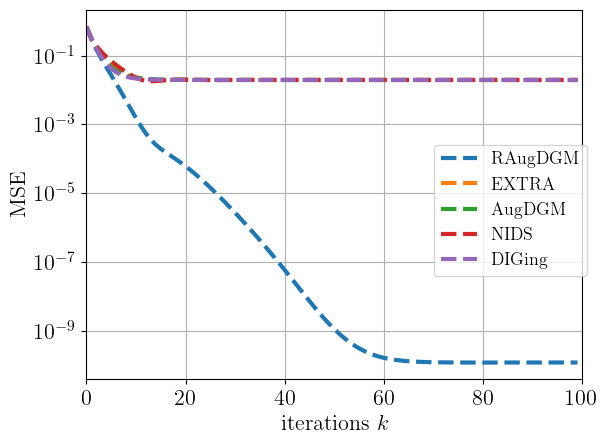

In [6]:
fig, ax = plt.subplots()

line_options = {"linewidth": 3, "linestyle": "--"}

hh: list[npt.NDArray[np.float64]] = []

nonrobust_algorithms = ["RAugDGM", "EXTRA", "AugDGM", "NIDS", "DIGing"]
for alg in nonrobust_algorithms:
    histories = local_histories[alg]
    # shape: (n_nodes, n_iter, dim)
    stacked_histories = stack(histories)
    # shape: (n_nodes, n_iter)
    mse_evolution_nodes = mean((stacked_histories - x_star) ** 2, axis=2)
    mse_evolution = mean(mse_evolution_nodes, axis=0)
    ax.semilogy(mse_evolution, label=alg, **line_options)
    hh.append(mse_evolution)

ax.set_xlim((0, 100))
ax.set_xlabel("iterations $k$")
ax.set_ylabel("MSE")
ax.legend(loc=(0.7, 0.28))
ax.grid(True, which="major", linestyle="-", linewidth=0.8)

## Shutdown the cluster

In [12]:
ray.shutdown()